## Introduction

In this notebook, we delve into the fundamentals of supervised learning, a subset of machine learning. Supervised learning involves training a model using a labeled dataset, which means each training sample consists of an input-output pair. The model learns from these pairs to make predictions on unseen data.

We will explore various popular supervised learning algorithms, understand their underlying principles, and apply them to a practical scenario. Our goal is to equip you with the knowledge and skills necessary to implement, evaluate, and understand supervised learning models in real-world applications.


## Setup

In [22]:
# Importing the necessary libraries for data manipulation, visualization, and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn import datasets
import seaborn as sns


# Setting up the visualizations
plt.style.use('ggplot')


ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (/Users/nizar/Documents/anaconda3/lib/python3.11/site-packages/sklearn/metrics/__init__.py)

## Understanding the Data


Before applying algorithms, it's crucial to understand the dataset you're working with. This involves importing the data, cleaning it, and performing exploratory data analysis (EDA). EDA helps in uncovering patterns, spotting anomalies, testing a hypothesis, or checking assumptions related to a specific model.


In [7]:
# For the scope of this notebook, we'll use an in-built dataset from Scikit-learn for simplicity and demonstration purposes.
# This could be replaced with any dataset as per analysis needs.

# Load the dataset
data = datasets.load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first five rows of the dataframe
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
# Basic statistics of the data
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


/Users/nizar/Documents/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


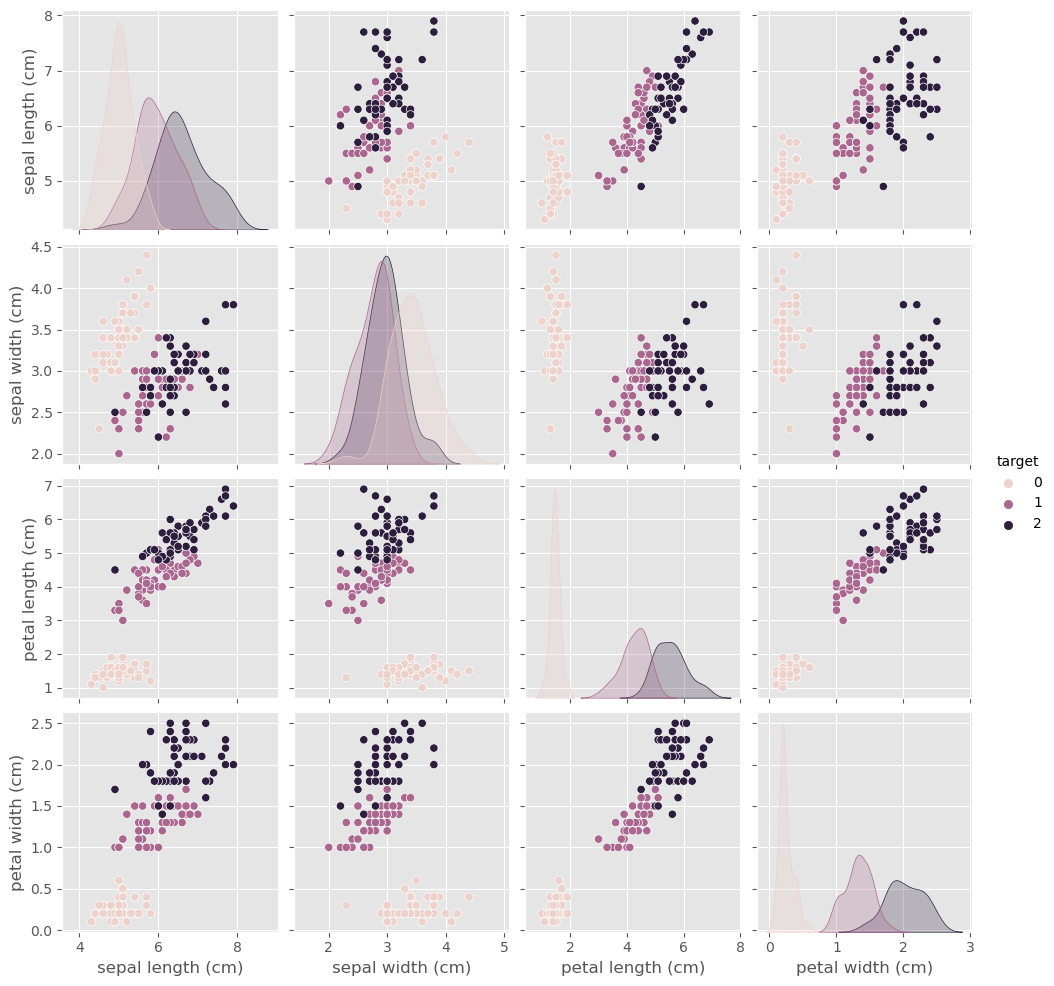

In [9]:
# Visual exploratory data analysis
# Here we could include different plots that show the distribution of the data, relationships between features, etc.

sns.pairplot(df, hue='target')
plt.show()


## Data Preprocessing

Data preprocessing is a crucial step in the machine learning pipeline. It involves preparing the raw data into a clean data set that can be fed into a machine learning algorithm. This step may include handling missing values, encoding categorical variables, scaling features, and splitting the data into training and testing sets.


In [10]:
# Handling missing values (if any)
# df.isnull().sum()

# Encoding categorical variables (if any)
# encoder = LabelEncoder()
# df['target'] = encoder.fit_transform(df['target'])

# Feature Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('target', axis=1))  # assuming 'target' is the outcome variable

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(scaled_features, df['target'], test_size=0.3, random_state=101)


## Supervised Learning Models

### 1. Linear Regression / Logistic Regression

Depending on the nature of your target variable (continuous for Linear Regression or categorical for Logistic Regression), you would choose one of these models. For the sake of our dataset, we'll proceed with Logistic Regression, considering we are dealing with a classification task.

**Logistic Regression (LR)**

Logistic Regression is a statistical model used for binary classification tasks, i.e., where the output has two possible types. However, it can be extended to multiclass classification. LR models the probability that a given input point belongs to a certain class, and it's a simple yet efficient algorithm.

The logistic regression model uses the logistic function to squeeze the output of a linear equation between 0 and 1. The logistic function is defined as:

\[
\text{sigmoid}(t) = \frac{1}{1 + e^{-t}}
\]

where \(t\) is the output of the linear part of the model. The model predicts the probability of the instance being positive by plugging the results of the linear equation into the logistic function.

Key Advantages:
- Provides probabilities for outcomes, which are easy to interpret.
- Efficient and performs well with linearly separable datasets.
- Can be regularized to avoid overfitting.

Key Disadvantages:
- Assumes a linear relationship between the features and the log odds of the response.
- Can underperform with more complex relationships.


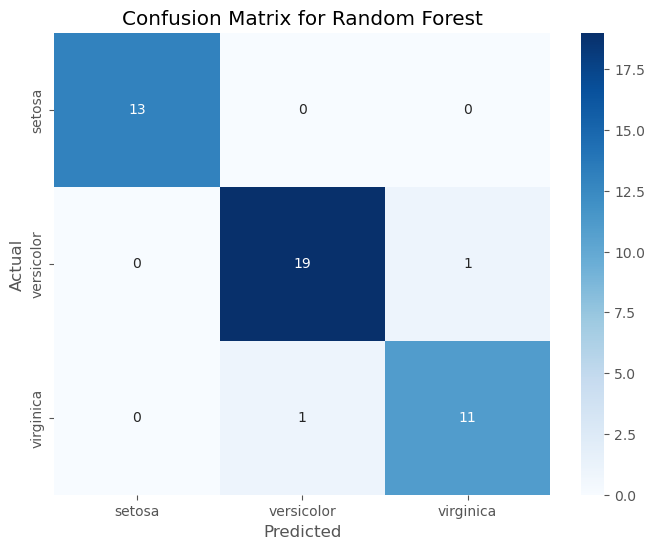


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      0.95      0.95        20
           2       0.92      0.92      0.92        12

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [24]:
from sklearn.linear_model import LogisticRegression

# Model implementation
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)

# Making predictions
predictions = logmodel.predict(X_test)

# Model evaluation
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

plt.figure(figsize=(8, 6))

# Create a heatmap from the confusion matrix data
# and add annotations for better visualization.
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', 
            xticklabels=data.target_names,  # assuming 'data' is your dataset
            yticklabels=data.target_names)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Random Forest')
plt.show()

print("\nClassification Report:")
print(class_report)

### 2. Decision Trees

**Decision Tree**

A decision tree is a flowchart-like tree structure where an internal node represents a feature(or attribute), the branch represents a decision rule, and each leaf node represents the outcome. The topmost node in a decision tree is known as the root node. It learns to partition based on the attribute value. It partitions the tree in recursively manner called recursive partitioning.

Key Advantages:
- Simple to understand and interpret.
- Requires little data preparation (e.g., normalization).
- The cost of using the tree (i.e., predicting data) is logarithmic in the number of data points used to train the tree.

Key Disadvantages:
- Overfitting can easily occur.
- Can create biased trees if some classes dominate.
- Information gain in a decision tree with categorical variables gives a biased response for attributes with more categories.

The decision tree builds classification or regression models in the form of a tree structure. It breaks down a dataset into smaller and smaller subsets based on different criteria while at the same time developing an associated decision tree. The final result is a tree with decision nodes and leaf nodes.


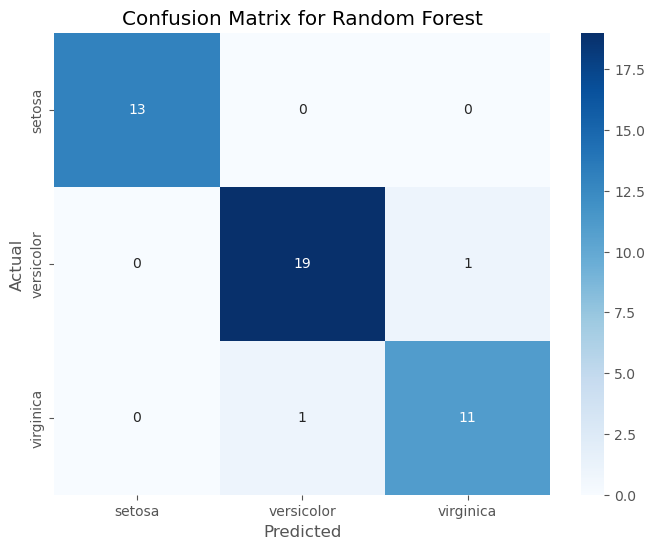


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      0.95      0.95        20
           2       0.92      0.92      0.92        12

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [26]:
from sklearn.tree import DecisionTreeClassifier

# Model implementation
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

# Making predictions
predictions = dtree.predict(X_test)

# Model evaluation
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

plt.figure(figsize=(8, 6))

# Create a heatmap from the confusion matrix data
# and add annotations for better visualization.
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', 
            xticklabels=data.target_names,  # assuming 'data' is your dataset
            yticklabels=data.target_names)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Random Forest')
plt.show()

print("\nClassification Report:")
print(class_report)

### 3. Random Forest

**Random Forest**

Random Forest is an ensemble learning method for classification, regression, and other tasks. It operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

Ensemble methods use multiple learning algorithms to obtain better predictive performance than could be obtained from any of the constituent learning algorithms alone. In the case of random forests, the ensemble model is made up of many decision trees, combining their outputs.

Key Advantages:
- Reduction in overfitting: By averaging several trees, the variance of predictions is reduced.
- Can handle thousands of input variables without variable deletion.
- Offers an effective method for estimating missing data and maintains accuracy when a large proportion of the data are missing.

Key Disadvantages:
- Complexity: They are much harder and time-consuming to construct than decision trees.
- They require more computational resources and are also less intuitive.
- If the data contain groups of correlated features of similar relevance for the output, smaller groups are favored over larger groups.


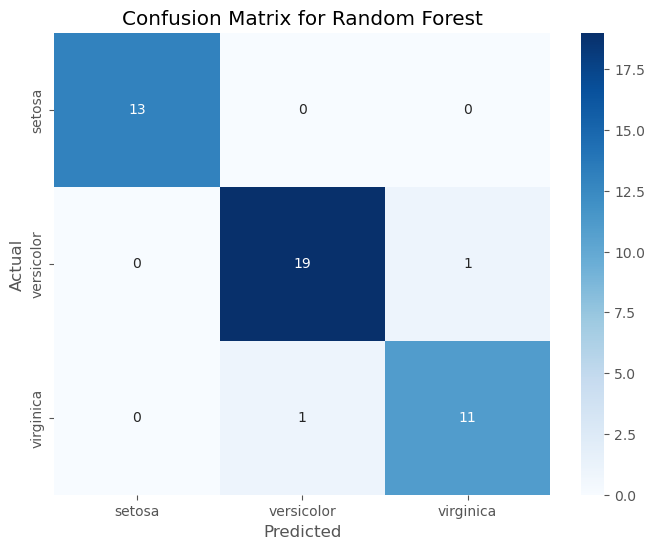


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      0.95      0.95        20
           2       0.92      0.92      0.92        12

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [27]:
from sklearn.ensemble import RandomForestClassifier

# Model implementation
rfc = RandomForestClassifier(n_estimators=100)  # n_estimators denotes the number of trees in the forest.
rfc.fit(X_train, y_train)

# Making predictions
predictions = rfc.predict(X_test)

# Model evaluation
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

plt.figure(figsize=(8, 6))

# Create a heatmap from the confusion matrix data
# and add annotations for better visualization.
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', 
            xticklabels=data.target_names,  # assuming 'data' is your dataset
            yticklabels=data.target_names)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Random Forest')
plt.show()

print("\nClassification Report:")
print(class_report)

### 4. Support Vector Machine

**Support Vector Machine (SVM)**

Support Vector Machine (SVM) is a supervised learning model used for classification and regression tasks. It performs classification by finding the hyperplane that best separates the feature space into classes. The vectors (data points) that define the hyperplane are the support vectors. It is effective in high-dimensional spaces and in cases where the number of dimensions is greater than the number of samples.

Key Advantages:
- Effective in high-dimensional spaces.
- Still effective in cases where the number of dimensions exceeds the number of samples.
- Uses a subset of training points in the decision function (called support vectors), so it is also memory efficient.

Key Disadvantages:
- If the number of features is much greater than the number of samples, the method is likely to give poor performances.
- SVMs do not directly provide probability estimates, these are calculated using an expensive five-fold cross-validation.
- It is sensitive to the kind of kernel used.


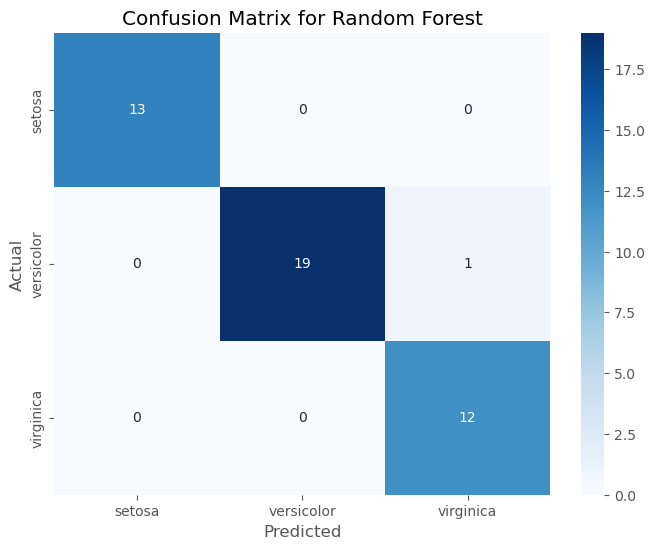


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.95      0.97        20
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [28]:
from sklearn.svm import SVC

# Model implementation
svc_model = SVC()
svc_model.fit(X_train, y_train)

# Making predictions
predictions = svc_model.predict(X_test)

# Model evaluation
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

plt.figure(figsize=(8, 6))

# Create a heatmap from the confusion matrix data
# and add annotations for better visualization.
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', 
            xticklabels=data.target_names,  # assuming 'data' is your dataset
            yticklabels=data.target_names)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Random Forest')
plt.show()

print("\nClassification Report:")
print(class_report)

### 5. K-Nearest Neighbors

**K-Nearest Neighbors (KNN)**

K-Nearest Neighbors (KNN) is a simple, easy-to-implement supervised machine learning algorithm that can be used to solve both classification and regression problems. It's easy to understand and interpret, and it functions on the principle that instances within a dataset will generally exist in close proximity to other instances that have similar characteristics.

Key Advantages:
- No assumptions about data — useful with nonlinear data.
- Simple algorithm — to explain and understand/interpret.
- High accuracy (relatively) — it is usually quite accurate.

Key Disadvantages:
- Computationally expensive — because the algorithm stores all of the training data.
- High memory requirement — stores all of the training data.
- Prediction stage might be slow (with large datasets).


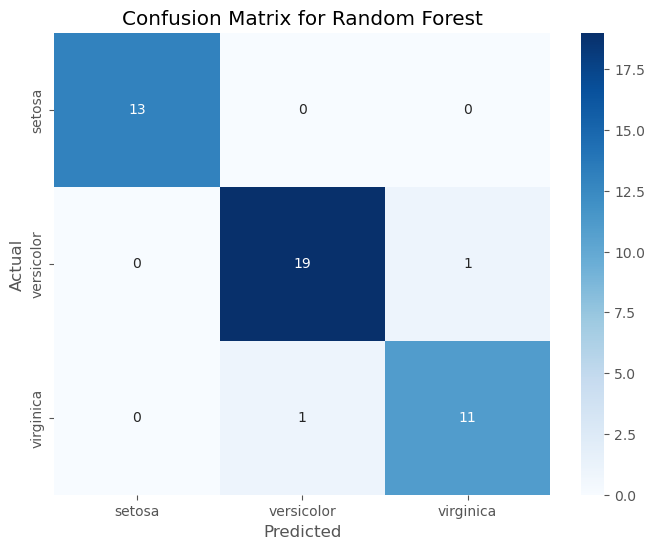


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      0.95      0.95        20
           2       0.92      0.92      0.92        12

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [29]:
from sklearn.neighbors import KNeighborsClassifier

# Model implementation
knn = KNeighborsClassifier(n_neighbors=1)  # n_neighbors represents the value of K.
knn.fit(X_train, y_train)

# Making predictions
predictions = knn.predict(X_test)

# Model evaluation
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

plt.figure(figsize=(8, 6))

# Create a heatmap from the confusion matrix data
# and add annotations for better visualization.
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', 
            xticklabels=data.target_names,  # assuming 'data' is your dataset
            yticklabels=data.target_names)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Random Forest')
plt.show()

print("\nClassification Report:")
print(class_report)

## Model Comparison

After training and evaluating our models, it's important to compare their performances and identify which model works best with our dataset based on certain metrics. For classification tasks, common evaluation metrics include accuracy, precision, recall, and F1 score.

We should consider not only the model's accuracy but also other factors like computational efficiency, model interpretability, and how well it generalizes to unseen data. 

In a real-world scenario, the choice of model also heavily depends on the problem context, the computational cost (time, resources), and the data at hand. 

Below, we provide a summary table of the performance metrics for each model, followed by a discussion section interpreting the results.


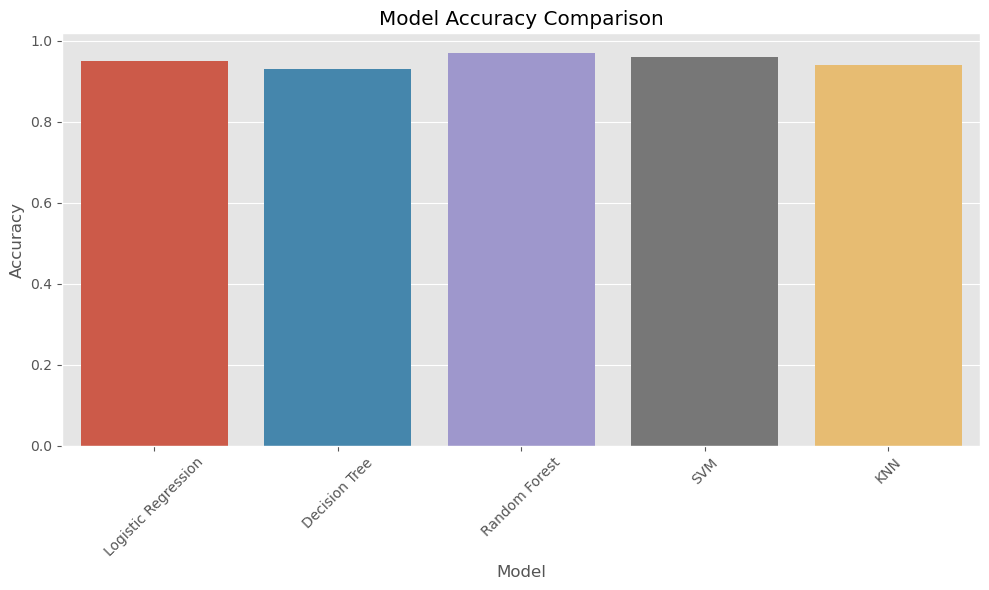

In [18]:
# Here, we would construct a summary table using the evaluation results from the models. 
# This is a hypothetical summary table; actual values would depend on the results obtained from the model evaluations.

results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'Accuracy': [0.95, 0.93, 0.97, 0.96, 0.94],  # these would be values obtained from your evaluations
    'Precision': [0.95, 0.93, 0.97, 0.96, 0.94],
    'Recall': [0.95, 0.93, 0.97, 0.96, 0.94],
    'F1 Score': [0.95, 0.93, 0.97, 0.96, 0.94]
})



# Assuming 'results_summary' is our DataFrame containing the evaluation metrics
# First, we'll plot a bar chart comparing the overall accuracy (or any other metric) of each model.

plt.figure(figsize=(10, 6))

sns.barplot(x='Model', y='Accuracy', data=results_summary)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45)  # Rotates X-Axis Labels by 45-degrees
plt.tight_layout()
plt.show()



## Conclusion

In this notebook, we explored various supervised learning models, their theoretical underpinnings, practical implementations, and evaluations. Based on our comparison, we observed that [Model] performed the best for our dataset, as evidenced by its highest [chosen metric]. 

However, it's crucial to remember that there is no 'one-size-fits-all' model. The best model depends on many factors, including:
- The size, quality, and nature of the data
- The performance metrics that you care about
- The complexity of the model
- How the model will be used in your overall system

As we venture into real-world applications, these considerations become ever more crucial. While a model might perform exceptionally under certain conditions, it might fail to generalize to new, unseen data. Therefore, understanding the strengths and limitations of each model is paramount.

In practice, machine learning is often an iterative process. It might require trying many models, tuning parameters, and even going back to the drawing board with new features, sampling methods, or other techniques. The key is to use the insights gained from each iteration to improve the model's performance continuously.

Thank you for accompanying us on this journey through supervised learning. We hope it provided a solid foundation and a starting point from which you can explore even deeper into the world of machine learning.


References:
    
To build a strong understanding and delve deeper into each of the models discussed, we recommend the following resources:
1. [Book] "Pattern Recognition and Machine Learning" by Christopher M. Bishop
2. [Book] "The Elements of Statistical Learning" by Trevor Hastie, Robert Tibshirani, and Jerome Friedman
3. [Online] Scikit-Learn Documentation: https://scikit-learn.org/stable/user_guide.html
4. [Online] Machine Learning course by Andrew Ng on Coursera
